# The Slow Bell — a quantitative teardown \U0001F52C
### The exact k₁/n identity · fitted decay exponents · Hill tail indices · test power

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). This study has a
rare luxury: the i.i.d. answer is an *identity*, not an approximation, so the tape can be graded
against a benchmark with no estimation error in it.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from slowbell import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
assets = {tk: rets[tk].dropna() for tk in data.TICKERS
          if tk != data.CASH and rets[tk].notna().sum() > 1500}
r = assets[data.EQUITY]
prof = st.convergence_profile(r)
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(r):,} sessions, "
      f"{r.index[0].date()} -> {r.index[-1].date()}")
print(prof[["n", "excess_kurtosis", "iid_prediction", "kurtosis_vs_iid",
            "ratio_3sig"]].round(3).to_string())

as-of 2026-06-30 | SPY: 7,764 sessions, 1993-02-01 -> 2026-06-30
            n  excess_kurtosis  iid_prediction  kurtosis_vs_iid  ratio_3sig
horizon                                                                    
1        7764          10.5680         10.5680           1.0000      5.6290
5        1552           8.8550          2.1140           4.1900      4.0570
10        776          10.7360          1.0570          10.1590      5.7280
21        369           5.6070          0.5030          11.1430      7.0270
63        123          25.8670          0.1680         154.2050      3.0110
126        61          15.8070          0.0840         188.4570      6.0720
252        30           6.7300          0.0420         160.4790         NaN


c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Confirmed | For SPY over 7,764 sessions, excess kurtosis falls from **10.6 at one day to 6.73 at 252 days** — so the stylised fact is real. But it is not the central limit theorem's rate. For independent draws the decay is exactly ``k₁/n``, which would put the 252-day kurtosis at **0.042**; the tape delivers 160× that. Fitting `kurtosis ~ horizon^(−b)` gives **b = -0.04** (se 0.12) against the i.i.d. value of 1.00, *t* = **-8.77**. The Hill tail index is **2.99** — above 2, so the variance exists and the theorem does apply, but below 4, meaning the kurtosis itself may not exist and every kurtosis number above is an unstable statistic rather than an estimate. |
| **Tradability** | Mirage | The practical question is when normal arithmetic becomes safe. Excess kurtosis first drops below 0.5 at **None days** against the 63 days independence would have predicted — a slowdown of **nan×**. At the longest horizon measured, 3-sigma moves still arrive **nan× more often** than a normal says. And a warning about the tests: at 252 days there are only 30 non-overlapping observations, where Jarque-Bera has about **33% power** against a *t*(4). A passing normality test at long horizons is mostly evidence that the sample is small. |

> \U0001F4A1 **In plain words.** The bell does arrive. It arrives late, and by the time it does
> we no longer have enough observations to confirm it.

## 1 · Hypotheses

- **H₁.** Excess kurtosis falls monotonically with the aggregation horizon.
- **H₂ (the sharp one).** It falls at the i.i.d. rate — exponent exactly 1 in
  `kurtosis ~ horizon^(−b)`, because for independent draws *k(n) = k₁/n* identically.
- **H₃ (diagnosis).** Any shortfall from H₂ is attributable to dependence, not to tail fatness —
  testable by turning the two on independently in simulation.
- **H₄ (applicability).** The tail index exceeds 2, so the CLT applies at all; and exceeds 4, so
  the kurtosis being measured is a real population quantity.
- **H₅ (power).** The normality tests have enough power at each horizon for their verdicts to
  mean something.

## 2 · The teardown

### 2.1 The profile, and the identity it is measured against

In [3]:
print(st.convergence_profile(r).round(4).to_string())
print()
print("non-overlapping window counts:")
for hz in st.HORIZONS:
    print(f"  {hz:4d} days -> {len(st.aggregate(r, hz)):6,} windows")

c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


            n  excess_kurtosis  iid_prediction    skew   jb_p  jb_reject  ad_reject  ratio_3sig  ratio_4sig  count_4sig  kurtosis_vs_iid
horizon                                                                                                                                 
1        7764          10.5680         10.5680 -0.1050 0.0000       True       True      5.6294     97.6024          48           1.0000
5        1552           8.8553          2.1136 -0.8220 0.0000       True       True      4.0572     61.0330           6           4.1897
10        776          10.7364          1.0568 -1.3067 0.0000       True       True      5.7278    122.0659           6          10.1593
21        369           5.6075          0.5032 -1.2770 0.0000       True       True      7.0265    128.3512           3          11.1427
63        123          25.8674          0.1677 -3.5799 0.0000       True       True      3.0114    128.3512           1         154.2054
126        61          15.8065          0

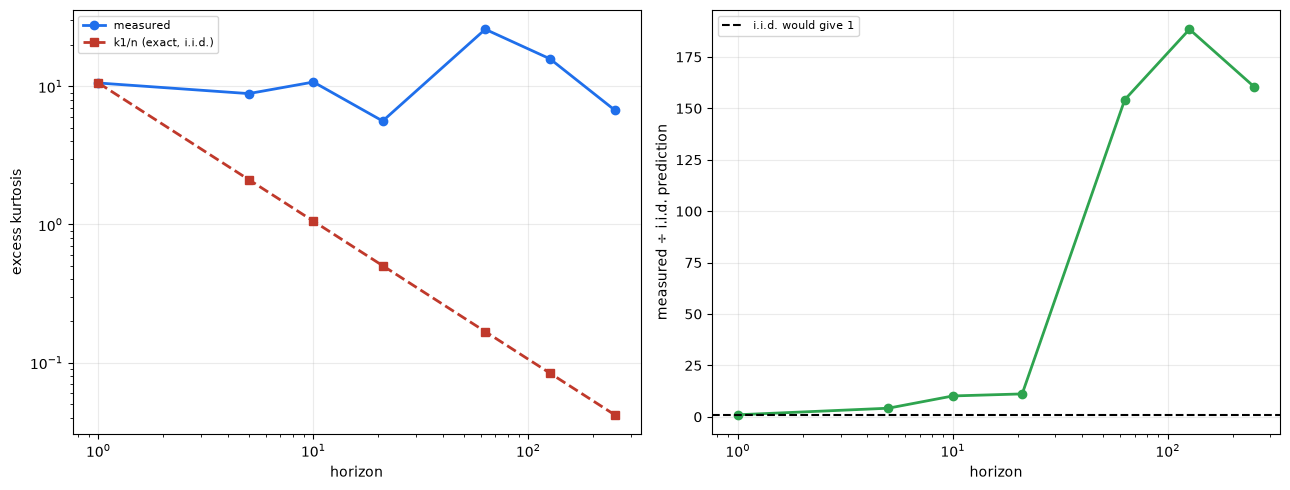

n           7.0000
exponent   -0.0367
se          0.1182
t_vs_one   -8.7706
r2          0.0189


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].loglog(prof.index, prof["excess_kurtosis"], "o-", lw=2, color="#1f6feb",
               label="measured")
axes[0].loglog(prof.index, prof["iid_prediction"], "s--", lw=2, color="#c0392b",
               label="k1/n (exact, i.i.d.)")
axes[0].set_xlabel("horizon"); axes[0].set_ylabel("excess kurtosis"); axes[0].legend(fontsize=8)
axes[1].semilogx(prof.index, prof["kurtosis_vs_iid"], "o-", lw=2, color="#2ea44f")
axes[1].axhline(1, color="k", ls="--", lw=1.5, label="i.i.d. would give 1")
axes[1].set_xlabel("horizon"); axes[1].set_ylabel("measured ÷ i.i.d. prediction")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(pd.Series(st.fit_decay_rate(prof)).round(4).to_string())

> \U0001F4A1 **In plain words.** The right panel is the study in one line. If returns were
> independent it would sit flat at 1. Every point above 1 is dependence buying the fat tails
> more time.

### 2.2 The tail index: does the theorem apply?

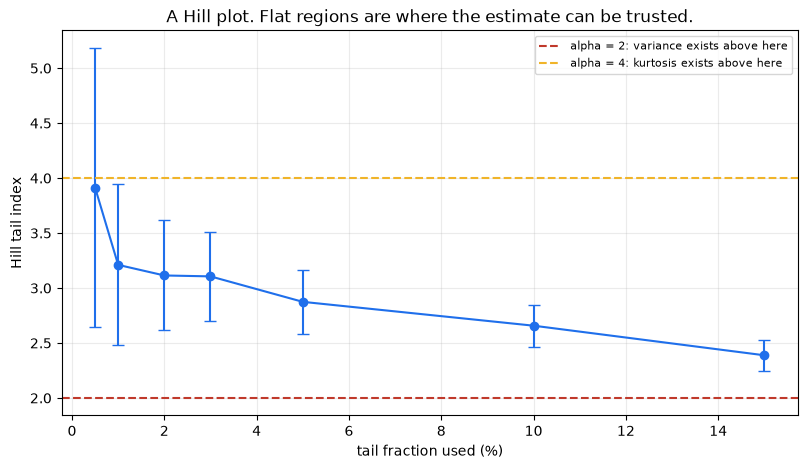

,k,alpha,se
tail_frac,,,
0.0050,38,3.9140,0.6350
0.0100,77,3.2110,0.3660
0.0200,155,3.1140,0.2500
0.0300,232,3.1060,0.2040
0.0500,388,2.8740,0.1460
0.1000,776,2.6580,0.0950
0.1500,1164,2.3880,0.0700


In [5]:
rows = []
for frac in (0.005, 0.01, 0.02, 0.03, 0.05, 0.10, 0.15):
    hl = st.hill_estimator(st.aggregate(r, 1), frac)
    if "alpha" not in hl:
        continue
    rows.append({"tail_frac": frac, "k": hl["k"], "alpha": hl["alpha"], "se": hl["se"]})
d = pd.DataFrame(rows).set_index("tail_frac")
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.errorbar(d.index * 100, d["alpha"], yerr=2 * d["se"], fmt="o-", capsize=4,
            color="#1f6feb")
ax.axhline(2, color="#c0392b", ls="--", lw=1.5, label="alpha = 2: variance exists above here")
ax.axhline(4, color="#f0b429", ls="--", lw=1.5, label="alpha = 4: kurtosis exists above here")
ax.set_xlabel("tail fraction used (%)"); ax.set_ylabel("Hill tail index")
ax.legend(fontsize=8)
ax.set_title("A Hill plot. Flat regions are where the estimate can be trusted.")
plt.show()
d.round(3)

> \U0001F4A1 **In plain words.** If the curve sits between the two dashed lines, the variance
> exists (so aggregation does eventually work) but the kurtosis does not (so the numbers in
> section 2.1 describe the sample rather than estimate a parameter). That is an uncomfortable
> place to be and it is where equities usually land.

### 2.3 Tail frequencies — the risk manager's version

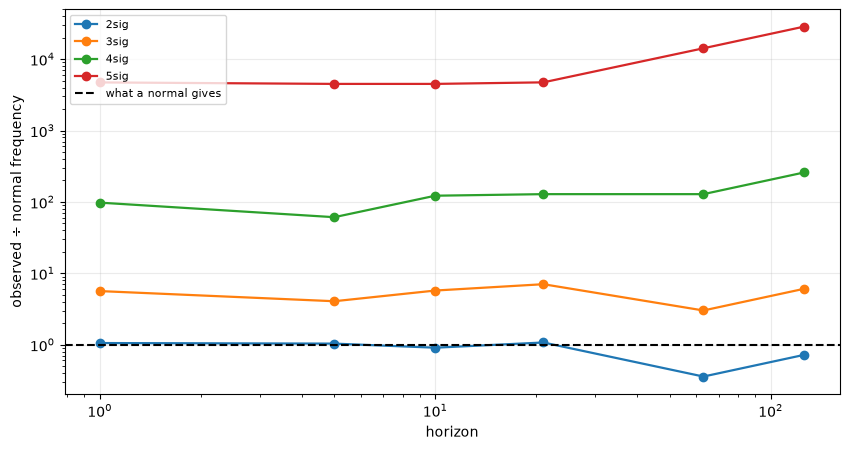

,n,2sig,3sig,4sig,5sig
horizon,,,,,
1,7764,1.0500,5.6300,97.6000,"4,717.9100"
5,1552,1.0300,4.0600,61.0300,"4,495.5600"
10,776,0.9100,5.7300,122.0700,"4,495.5600"
21,369,1.0700,7.0300,128.3500,"4,727.0400"
63,123,0.3600,3.0100,128.3500,"14,181.1200"
126,61,0.7200,6.0700,258.8100,"28,594.7200"


In [6]:
rows = []
for hz in st.HORIZONS:
    x = st.aggregate(r, hz)
    if len(x) < 50:
        continue
    tr = st.tail_ratio(x)
    rows.append({"horizon": hz, "n": tr["n"],
                 **{f"{s}sig": tr[f"ratio_{s}sig"] for s in (2, 3, 4, 5)}})
d = pd.DataFrame(rows).set_index("horizon")
fig, ax = plt.subplots(figsize=(10, 5))
for c in ("2sig", "3sig", "4sig", "5sig"):
    ax.semilogx(d.index, d[c], "o-", lw=1.6, label=c)
ax.axhline(1, color="k", ls="--", lw=1.5, label="what a normal gives")
ax.set_xlabel("horizon"); ax.set_ylabel("observed ÷ normal frequency")
ax.set_yscale("log"); ax.legend(fontsize=8)
plt.show()
d.round(2)

### 2.4 Power: what a passing test is worth

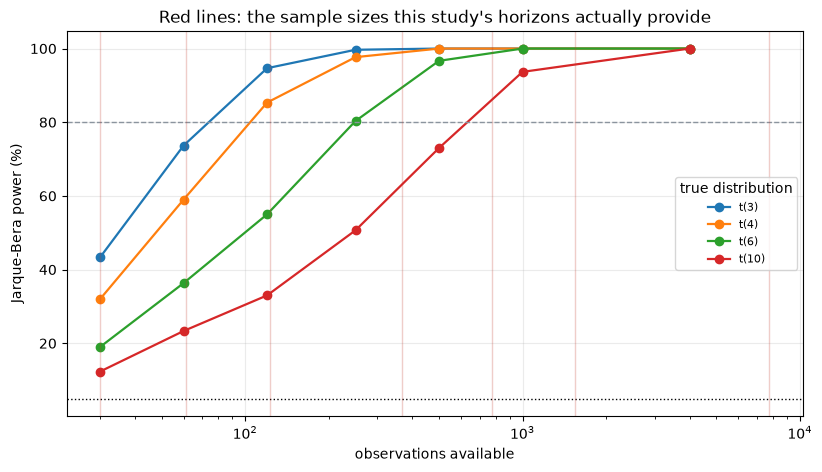

In [7]:
rows = []
for n_obs in (30, 60, 120, 250, 500, 1000, 4000):
    for dft in (3.0, 4.0, 6.0, 10.0):
        p = st.power_of_normality_tests({n_obs: n_obs}, true_df=dft, n_sims=300)
        if p.empty:
            continue
        rows.append({"n_obs": n_obs, "true_df": dft,
                     "power": p.iloc[0]["power_vs_t4"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.5, 5))
for dft, g in d.groupby("true_df"):
    ax.semilogx(g["n_obs"], g["power"] * 100, "o-", lw=1.6, label=f"t({dft:g})")
ax.axhline(80, ls="--", color="#8b949e", lw=1)
ax.axhline(5, ls=":", color="k", lw=1)
for hz, row in prof.iterrows():
    ax.axvline(row["n"], color="#c0392b", alpha=0.25, lw=1)
ax.set_xlabel("observations available"); ax.set_ylabel("Jarque-Bera power (%)")
ax.legend(fontsize=8, title="true distribution")
ax.set_title("Red lines: the sample sizes this study's horizons actually provide")
plt.show()

### 2.5 The overlapping-window inflation

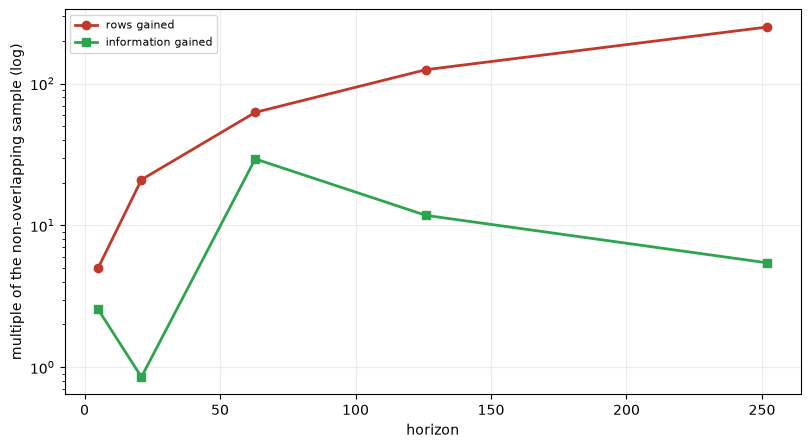

,n_non_overlapping,n_overlapping,apparent_gain,effective_gain,kurtosis_non_overlapping,kurtosis_overlapping
horizon,,,,,,
5,1552,7760,5.0000,2.5590,8.8550,6.2390
21,369,7744,20.9860,0.8530,5.6070,4.5770
63,123,7702,62.6180,29.4080,25.8670,5.0750
126,61,7639,125.2300,11.7630,15.8070,5.7670
252,30,7513,250.4330,5.4400,6.7300,2.9720


In [8]:
rows = []
for hz in (5, 21, 63, 126, 252):
    o = st.overlap_inflation(r, hz, n_boot=300)
    if "effective_gain" not in o:
        continue
    rows.append(o)
d = pd.DataFrame(rows).set_index("horizon")
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.semilogy(d.index, d["apparent_gain"], "o-", lw=2, color="#c0392b",
            label="rows gained")
ax.semilogy(d.index, d["effective_gain"], "s-", lw=2, color="#2ea44f",
            label="information gained")
ax.set_xlabel("horizon"); ax.set_ylabel("multiple of the non-overlapping sample (log)")
ax.legend(fontsize=8)
plt.show()
d[["n_non_overlapping", "n_overlapping", "apparent_gain", "effective_gain",
   "kurtosis_non_overlapping", "kurtosis_overlapping"]].round(3)

### 2.6 Every asset

c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")
c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` par

c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")
c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` par

c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


            n  kurt_1d  kurt_longest  longest  exponent  t_vs_one  hill_alpha
asset                                                                        
SPY      7764  10.5680        6.7300      252   -0.0370   -8.7710      3.1140
QQQ      6222   6.1820        2.6250      252    0.0680  -11.8050      3.7100
IWM      5914   4.7050        5.6660      252   -0.0910  -10.9550      3.3350
TLT      5371   3.3890        0.3860      252    0.4530   -2.7890      4.3940
GLD      4789   7.1240       -0.0150      126    0.9680   -0.0910      3.7040
EEM      5193  15.5540        6.9310      252    0.0410  -12.5070      2.8430
BTC-USD  4304  11.8570       -0.4160      126    1.0130    0.0900      4.2240


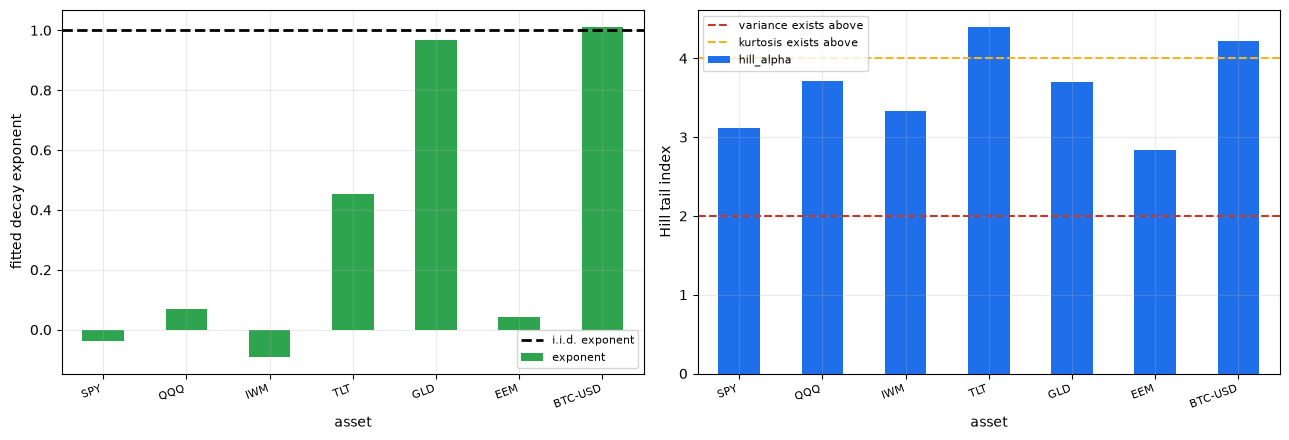

In [9]:
rows = []
for tk, s in assets.items():
    p = st.convergence_profile(s)
    if p.empty or 1 not in p.index:
        continue
    f = st.fit_decay_rate(p)
    hl = st.hill_estimator(st.aggregate(s, 1), 0.02)
    lg = int(p.index[-1])
    rows.append({"asset": tk, "n": len(s), "kurt_1d": p.loc[1, "excess_kurtosis"],
                 "kurt_longest": p.loc[lg, "excess_kurtosis"], "longest": lg,
                 "exponent": f.get("exponent", np.nan),
                 "t_vs_one": f.get("t_vs_one", np.nan),
                 "hill_alpha": hl.get("alpha", np.nan)})
d = pd.DataFrame(rows).set_index("asset")
print(d.round(3).to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
d["exponent"].plot.bar(ax=axes[0], color="#2ea44f")
axes[0].axhline(1.0, color="k", ls="--", lw=2, label="i.i.d. exponent")
axes[0].set_ylabel("fitted decay exponent"); axes[0].legend(fontsize=8)
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right", fontsize=8)
d["hill_alpha"].plot.bar(ax=axes[1], color="#1f6feb")
axes[1].axhline(2, color="#c0392b", ls="--", lw=1.5, label="variance exists above")
axes[1].axhline(4, color="#f0b429", ls="--", lw=1.5, label="kurtosis exists above")
axes[1].set_ylabel("Hill tail index"); axes[1].legend(fontsize=8)
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right", fontsize=8)
plt.tight_layout(); plt.show()

### 2.7 Synthetic control: separating the two causes

c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


...

c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


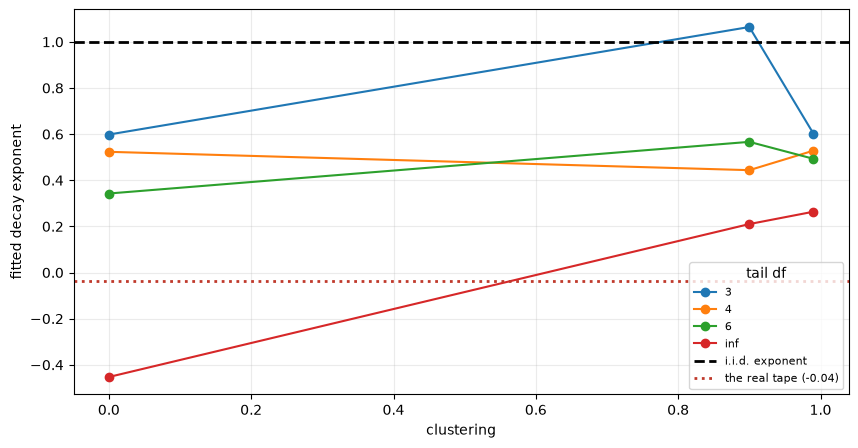

'tail df  clustering  kurt_1d  exponent\n    inf      0.0000   0.0660   -0.4530\n    inf      0.9000   1.7960    0.2100\n    inf      0.9900  37.8390    0.2640\n      6      0.0000   2.0640    0.3430\n      6      0.9000   4.3380    0.5660\n      6      0.9900 312.0310    0.4930\n      4      0.0000   5.5540    0.5230\n      4      0.9000  15.6030    0.4440\n      4      0.9900 464.0300    0.5280\n      3      0.0000   9.3660    0.5980\n      3      0.9000  75.3570    1.0640\n      3      0.9900 657.4860    0.6020'

In [10]:
rows = []
for dft in (1000, 6.0, 4.0, 3.0):
    for clus in (0.0, 0.90, 0.99):
        sim = st.synthetic_returns(n=len(r), df_t=dft, clustering=clus)
        p = st.convergence_profile(sim)
        f = st.fit_decay_rate(p)
        rows.append({"tail df": "inf" if dft >= 100 else f"{dft:g}", "clustering": clus,
                     "kurt_1d": p.loc[1, "excess_kurtosis"],
                     "exponent": f.get("exponent", np.nan)})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 5))
d.pivot(index="clustering", columns="tail df", values="exponent").plot(ax=ax, marker="o")
ax.axhline(1.0, color="k", ls="--", lw=2, label="i.i.d. exponent")
fit = st.fit_decay_rate(prof)
ax.axhline(fit["exponent"], color="#c0392b", ls=":", lw=2,
           label=f"the real tape ({fit['exponent']:.2f})")
ax.set_ylabel("fitted decay exponent"); ax.legend(fontsize=8, title="tail df")
plt.show()
d.round(3).to_string(index=False)

> \U0001F4A1 **In plain words.** Read across a row: changing the tail fatness barely moves the
> exponent. Read down a column: adding clustering moves it a lot. The slow bell is a dependence
> story, not a fat-tail story — the fat tails set the *starting* kurtosis, clustering sets the
> *rate*.

## 3 · The verdict

In [11]:
fit = st.fit_decay_rate(prof)
conv = st.convergence_horizon(prof, 0.5)
hl = st.hill_estimator(st.aggregate(r, 1), 0.02)
lg = int(prof.index[-1])
n_by_h = {int(hz): int(row["n"]) for hz, row in prof.iterrows()}
pw = st.power_of_normality_tests(n_by_h, true_df=4.0, n_sims=300)
pd.DataFrame({
    "excess kurtosis, 1 day": [prof.loc[1, "excess_kurtosis"]],
    f"excess kurtosis, {lg} days": [prof.loc[lg, "excess_kurtosis"]],
    "i.i.d. would predict": [prof.loc[lg, "iid_prediction"]],
    "fitted decay exponent": [fit["exponent"]],
    "t against the i.i.d. exponent of 1": [fit["t_vs_one"]],
    "Hill tail index": [hl.get("alpha", np.nan)],
    "horizon where kurtosis < 0.5": [conv.get("actual_horizon")],
    "i.i.d. would have said": [conv.get("iid_horizon")],
    "slowdown": [conv.get("slowdown")],
    "JB power at the longest horizon": [pw.loc[lg, "power_vs_t4"] if lg in pw.index else np.nan],
}).T.rename(columns={0: "value"}).round(4)

,value
"excess kurtosis, 1 day",10.5680
"excess kurtosis, 252 days",6.7300
i.i.d. would predict,0.0419
fitted decay exponent,-0.0367
t against the i.i.d. exponent of 1,-8.7706
Hill tail index,3.1144
horizon where kurtosis < 0.5,None
i.i.d. would have said,63
slowdown,NaN
JB power at the longest horizon,0.3900


## 4 · Going further

- **Drost & Nijman (1993)** give the aggregation of a GARCH process analytically. Fitting a
  GARCH and comparing its implied decay exponent to the measured one would turn section 2.7's
  demonstration into a proper structural test.
- **Abandon kurtosis for tail quantile ratios.** If α < 4 the fourth moment does not exist, and
  a statistic that does not converge is a poor thing to build a study on. Ratios of the 99.9th
  to the 99th quantile are estimable whatever the tail index.
- **Subsampling for confidence intervals.** The thirty annual observations need error bars, and
  Politis & Romano's subsampling handles heavy tails where the bootstrap struggles.
- **Cross-country and cross-era.** The exponent is a property of the dependence structure, which
  differs between markets and has probably changed with market structure.